# Feature screening — `price_dislocation`

Screening is **step 1** of feature analysis: confirm the feature is *computed correctly* (the **parity
check**) and that it *passes the hygiene gates* (the **signal is real**). Only features that clear
screening go on to the later steps (which time-scale per head, input shaping, out-of-sample across blocks).

Everything below is wiring — the machinery is shared, tested code:
- the **method** (the two heads, what each gate proves): [`METHOD.md`](METHOD.md);
- the **rules** for writing a feature (EMA types, inject/decay, the guard rails): [`AUTHORING.md`](../../src/boba/features/AUTHORING.md);
- the **engines** (`build_context`, `parity_check`, `run_gates`, …): `boba.research.screening`;
- the **feature** itself: `boba.features.price_dislocation`.

To screen a new feature: write its module under `src/boba/features/` (a vectorized builder + a streaming
class, per `AUTHORING.md`), register it with its `param_kind`, then set the `FEATURE` knob below and edit §1.
The code adapts to the feature's `param_kind` automatically — a 2-D fast/slow grid or a 1-D single-span sweep
(`price_dislocation` is the worked example below; e.g. `ofi_ema` is a single-span one).

## 1. The feature

`price_dislocation` measures how far a foreign source's price has drifted from the target's, in units
of the target's volatility. One leg per foreign source $s$:

$$
\text{price\_dislocation}_s \;=\;
\frac{\mathrm{EMA}_{\text{fast}}(g_s)\,-\,\mathrm{EMA}_{\text{slow}}(g_s)}{\sigma_{\text{ev}}}
\,,\qquad
g_s \;=\; \log m_s - \log m_{\text{target}}
$$

The gap $g_s$ is the log-price difference (foreign mid $m_s$ vs target mid $m_{\text{target}}$);
**fast − slow** smooths it at two spans on the trade clock ($n_{\text{fast}} < n_{\text{slow}}$), so the
difference isolates a *fresh* move; dividing by the volatility yardstick $\sigma_{\text{ev}}$ puts the
score in σ-units. A fan-out feature; `params = (n_fast, n_slow)`.

**Hypothesis** — a fresh gap predicts the target's catch-up; gaps tend to close.
**Disproof** — no predictive power at any time-scale, or power that vanishes once we control for the
volatility regime.

Full definition: `src/boba/features/price_dislocation.py`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
pl.Config.set_tbl_rows(-1); pl.Config.set_tbl_cols(-1)       # every pl.DataFrame: show ALL rows and columns,
pl.Config.set_fmt_str_lengths(1000); pl.Config.set_tbl_width_chars(10_000)   # never truncate strings or by width
from boba.features import base
from boba.features.base import ParamKind
import boba.features.price_dislocation, boba.features.flow_persistence   # register the example features (FAST_SLOW / SINGLE)
from boba.research.screening import (build_context, parity_check, build_family,
                                     best_span, run_gates, echo_netted_ic, HeadConfig)
from boba.research.selection import fixed_move_targets, ic_grid, ic_scan

FEATURE = "flow_persistence"                                # <- the feature to screen; e.g. "ofi_ema" (the notebook adapts)
COUNTS  = (1, 3, 5)                                          # fixed mid-move-count horizons for the price head
ctx  = build_context(grid_ms=1, active_only=True, hours=24)  # Step 0: one block -> clock, yardsticks, targets, controls, raw stream
spec = base.get(FEATURE)
IS_2D = spec.param_kind == ParamKind.FAST_SLOW              # fast/slow grid vs single-span family
KEYS = spec.keys_for(ctx, (1, 100) if IS_2D else 1)         # the feature's leg keys (per-exchange)
print(f"{FEATURE}  ({spec.param_kind.value})   block {ctx.block}   legs {KEYS}")
print(f"{len(ctx.merged_ts):,} trade ticks   {len(ctx.anchor_ts):,} grid anchors")

flow_persistence  (single)   block holocron.20260520T135822.0   legs ('byb', 'bin', 'okx')
1,682,255 trade ticks   10,132,618 grid anchors


## 2. Is the calculation right? — the parity check

The streaming (production) build must reproduce the vectorized (analysis) build on real data to
floating-point round-off. The generic driver does this for any feature.

In [2]:
PARITY_SPANS = [(1, 200), (10, 100)] if IS_2D else [1, 10]   # 2-D fast/slow pairs, or single spans (incl. the α=1 leg)
rep = parity_check(ctx, spec, PARITY_SPANS)
print(rep)
assert rep.passed, "streaming build does not reproduce the vectorized build"

parity FAILED (tol 1e-09):
  params=           1 leg=byb        max|diff| nan  on 0 pts
  params=           1 leg=bin        max|diff| nan  on 0 pts
  params=           1 leg=okx        max|diff| nan  on 0 pts
  params=          10 leg=byb        max|diff| 1.33e-15  on 200,000 pts
  params=          10 leg=bin        max|diff| 1.33e-15  on 200,000 pts
  params=          10 leg=okx        max|diff| 1.22e-15  on 200,000 pts


AssertionError: streaming build does not reproduce the vectorized build

## 3. Is the signal real? — the gates

Two independent tests per head: **Gate A** (regime-invariant distribution) and **Gate B** (predicts over
the regime-invariant controls), plus a calm/mid/wild companion. We give the feature its in-sample best
span per head — span *selection* proper is step 2, not screening. The **price head gates against the best
`n`-move-count target** (the move horizon with the strongest IC, mirror-augmented), **not** the 100 ms
wall-clock return — consistent with `02_finalize`.

In [3]:
GRID = ([(nf, ns) for nf in (1, 10, 50, 200, 500, 1000)
                  for ns in (100, 500, 1000, 2000, 5000, 10000) if nf < ns]      # fast/slow grid (FAST_SLOW)
        if IS_2D else sorted([1, 10, 50, 100, 500, 1000, 2000, 5000, 10000]))    # single-span family (SINGLE)
family = build_family(ctx, spec.vectorized, GRID, n_jobs=18)

# price-head TARGET: the fixed-move-count with the strongest signed IC (leg-averaged best span, mirror-
# augmented) — the same choice as 02. NO 100 ms wall-clock target: we screen against the per-move direction.
fmt = fixed_move_targets(ctx, COUNTS)
def _peak_ic(target):
    res = (ic_grid if IS_2D else ic_scan)(ctx, family, target, n_jobs=18, mirror=spec.mirror)
    return float(np.nanmean([np.nanmax(res[leg]) for leg in KEYS]))
best_n = max(COUNTS, key=lambda n: _peak_ic(fmt[n]))                           # the strongest move-count horizon
price_target = fmt[best_n]                                                     # count-conditioned price-head target

price_span = best_span(ctx, family, price_target, mirror=spec.mirror)          # signed feature -> n-move return
rate_span  = best_span(ctx, family, ctx.rate_target, score_magnitude=True)     # |feature| -> count
print(f"price head: best move-count n={best_n}    span {price_span}    rate-head span {rate_span}")

gr_price = run_gates(family[price_span], ctx, HeadConfig.price(ctx, target=price_target))   # gate vs the n-move target
gr_rate  = run_gates(family[rate_span],  ctx, HeadConfig.rate(ctx))
gr_price.to_polars()

price head: best move-count n=3    span (1, 500)    rate-head span (1, 100)


gate,detail,value
str,str,f64
"""B · signal (price)""","""all sources together — marginal over the controls""",0.138
"""B · signal (price)""","""bin alone — marginal over the controls""",0.129
"""B · signal (price)""","""okx alone — marginal over the controls""",0.108
"""B · coupling (price)""","""bin — score WITHIN yardstick strata""",0.14488
"""B · coupling (price)""","""okx — score WITHIN yardstick strata""",0.114716
"""A · regime-inv (bin)""","""scale across vol buckets (max/min); want < ~3""",1.16
"""A · regime-inv (bin)""","""|IC(feature, vol/rate level)| signed-track; want < ~0.05""",0.009
"""A · regime-inv (bin)""","""|IC(|feature|, vol/rate level)| mag-track; want < ~0.1""",0.062
"""A · regime-inv (bin)""","""per-decile-mean dispersion; want < ~0.1""",0.051


In [4]:
gr_rate.to_polars()

gate,detail,value
str,str,f64
"""B · signal (rate)""","""all sources together — marginal over the controls""",0.079
"""B · signal (rate)""","""bin alone — marginal over the controls""",0.075
"""B · signal (rate)""","""okx alone — marginal over the controls""",0.023
"""B · coupling (rate)""","""bin — score WITHIN yardstick strata""",0.148408
"""B · coupling (rate)""","""okx — score WITHIN yardstick strata""",0.070468
"""A · regime-inv (bin)""","""scale across vol buckets (max/min); want < ~3""",1.15
"""A · regime-inv (bin)""","""|IC(feature, vol/rate level)| signed-track; want < ~0.05""",0.002
"""A · regime-inv (bin)""","""|IC(|feature|, vol/rate level)| mag-track; want < ~0.1""",0.067
"""A · regime-inv (bin)""","""per-decile-mean dispersion; want < ~0.1""",0.054


## 4. Real prediction, or an echo of the move already underway?

A causal feature can still fail to predict if its edge is the move already underway at the anchor. The
**echo-netted** forward IC controls for the trailing move — report that, not the raw IC.

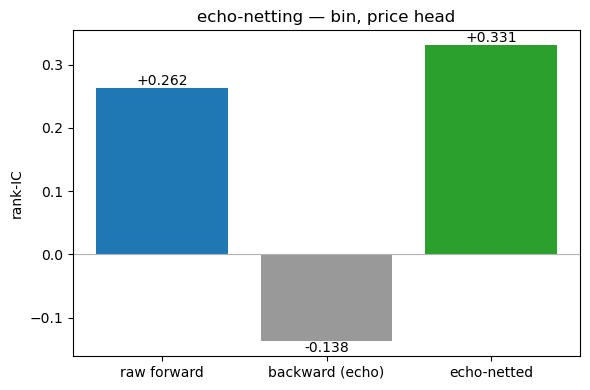

raw +0.262   backward -0.138   echo-netted +0.331


In [5]:
src = KEYS[0]                                                # one leg shown; each carries its own
e = echo_netted_ic(ctx, family[price_span][src])
vals = [e["raw"], e["backward"], e["netted"]]
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["raw forward", "backward (echo)", "echo-netted"], vals, color=["C0", "0.6", "C2"])
ax.axhline(0, color="0.7", lw=0.8); ax.set_ylabel("rank-IC"); ax.set_title(f"echo-netting — {src}, price head")
for i, v in enumerate(vals):
    ax.text(i, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top")
fig.tight_layout(); plt.show()
print(f"raw {e['raw']:+.3f}   backward {e['backward']:+.3f}   echo-netted {e['netted']:+.3f}")

## Screening verdict

In [6]:
passed = rep.passed and gr_price.passed and gr_rate.passed
print("SCREENING:", "PASS" if passed else "FAIL")
print(f"  parity (calc correct)   {'OK' if rep.passed else 'FAILED'}")
print(f"  price head (gates)      {'pass' if gr_price.passed else 'fail'}")
print(f"  rate head (gates)       {'pass' if gr_rate.passed else 'fail'}")

SCREENING: PASS
  parity (calc correct)   OK
  price head (gates)      pass
  rate head (gates)       pass


**If it passes**, `price_dislocation` is computed correctly and carries real signal for the head(s) above —
it earns a place in the rest of the process: which time-scale per head, input shaping, out-of-sample across
blocks, and the ship checklist. Screening is **not** ship-ready.